# Clean SNOTEL Idaho / AWDB workflow

## Notebook overview

This notebook builds a clean, resumable workflow for Idaho SNOTEL and AWDB data.
It is designed to support station screening, multi-variable downloads, yearly chunking,
quality checks, and exploratory analysis of snow, temperature, and precipitation.

### Main steps covered in this notebook

1. Load the official Idaho SNOTEL station inventory.
2. Query AWDB station metadata and available elements.
3. Build the list of available `(elementCd, duration)` combinations.
4. Download AWDB time series in yearly chunks with restart-safe logic.
5. Skip files that already exist to avoid unnecessary re-downloads.
6. Merge downloaded chunks into analysis-ready tables.
7. Plot completeness, compare Synoptic vs non-Synoptic stations, and summarize data coverage.
8. Build climatologies and recent-year comparisons for SWE, temperature, and precipitation.
9. Aggregate results by elevation band for Idaho-wide diagnostics.

### General notebook design choices

- Outputs are cached on disk whenever possible.
- Existing files are skipped unless explicitly overwritten.
- Large downloads are split into yearly chunks to make the workflow restartable.
- The same station metadata are reused across all downstream analyses.
- Water year is used throughout the notebook (October 1 to September 30).

# Clean SNOTEL Idaho / AWDB workflow

Reproducible and restartable notebook for:

1. loading the official Idaho SNOTEL inventory  
2. downloading AWDB station elements  
3. downloading **daily** time series in yearly chunks  
4. downloading **radiation** time series in yearly chunks  
5. concatenating chunks and plotting completeness  
6. comparing **Synoptic vs non-Synoptic** stations  
7. building SWE, temperature, and precipitation diagnostics  

Design principles used throughout the notebook:
- skip work if the final file already exists
- write temporary files first, then replace atomically
- keep all water-year logic explicit
- keep the workflow modular so each block can be rerun independently

In [1]:
from __future__ import annotations
import os
import glob
import time
import hashlib
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from zeep import Client
from zeep.transports import Transport

WSDL = "https://wcc.sc.egov.usda.gov/awdbWebService/services?WSDL"

OUT_DIR = Path("out")
OUT_DIR.mkdir(exist_ok=True)

def file_ready(path, min_size_bytes=100):
    path = Path(path)
    return path.exists() and path.stat().st_size > min_size_bytes

def atomic_to_csv(df, out_csv):
    out_csv = Path(out_csv)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    tmp_csv = out_csv.with_suffix(out_csv.suffix + ".tmp")
    df.to_csv(tmp_csv, index=False)
    os.replace(tmp_csv, out_csv)

def build_awdb_client(timeout=120):
    session = requests.Session()
    session.headers.update({"User-Agent": "awdb-snotel-clean/1.0"})
    transport = Transport(session=session, timeout=timeout)
    return Client(wsdl=WSDL, transport=transport)

client = build_awdb_client(timeout=120)
print("AWDB client ready")

AWDB client ready


## 1. Load Idaho official inventory

In [2]:
STATION_META_CSV = "out/snotel_official_inventory_idaho_clean.csv"

df_station_meta = pd.read_csv(STATION_META_CSV, dtype={"station_triplet": "string"})
df_station_meta["station_triplet"] = df_station_meta["station_triplet"].str.strip()

triplets = (
    df_station_meta["station_triplet"]
    .dropna()
    .drop_duplicates()
    .tolist()
)

print("Stations in inventory:", len(df_station_meta))
print("Triplets:", len(triplets))
display(df_station_meta.head())

Stations in inventory: 85
Triplets: 85


,station_triplet,station_id,site_name,lat,lon,elev_ft,elev_m,county,huc,start,start_year,por_years_approx,source
0,306:ID:SNTL,306,Atlanta Summit (306),43.76,-115.24,7570,2307.336,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,1978-October,1978,48,SNOTEL_OFFICIAL
1,312:ID:SNTL,312,Banner Summit (312),44.30,-115.23,7040,2145.792,Boise,Canyon Creek (170501200202),1979-October,1979,47,SNOTEL_OFFICIAL
2,319:ID:SNTL,319,Bear Basin (319),44.95,-116.14,5350,1630.680,Adams,Little Goose Creek-Goose Creek (170602100104),1979-October,1979,47,SNOTEL_OFFICIAL
3,320:ID:SNTL,320,Bear Canyon (320),43.74,-113.94,7920,2414.016,Custer,Upper Star Hope Creek (170402180101),1979-October,1979,47,SNOTEL_OFFICIAL
4,323:ID:SNTL,323,Bear Mountain (323),48.31,-116.07,5460,1664.208,Bonner,Middle Lightning Creek (170102131202),1979-October,1979,47,SNOTEL_OFFICIAL


## 2. Download AWDB station elements with disk cache

In [3]:
CACHE_DIR = OUT_DIR / "cache_awdb_elements"
CACHE_DIR.mkdir(exist_ok=True)

EL_OUT = OUT_DIR / "awdb_idaho_station_elements_long.csv"
ERR_OUT = OUT_DIR / "awdb_idaho_station_elements_errors.csv"

def safe_name(s):
    return "".join(c if c.isalnum() or c in "_-:." else "_" for c in str(s))

def fetch_station_elements_cached(triplet, begin="", end="", sleep_seconds=0.1):
    key = f"{triplet}|{begin}|{end}"
    h = hashlib.md5(key.encode()).hexdigest()
    cache_csv = CACHE_DIR / f"{safe_name(triplet)}__{h}.csv"

    if file_ready(cache_csv):
        return pd.read_csv(cache_csv)

    elements = client.service.getStationElements(triplet, begin, end)

    rows = []
    if elements:
        for e in elements:
            rows.append({
                "stationTriplet": getattr(e, "stationTriplet", triplet),
                "elementCd": getattr(e, "elementCd", None),
                "duration": getattr(e, "duration", None),
                "beginDate": str(getattr(e, "beginDate", "")) if getattr(e, "beginDate", None) is not None else "",
                "endDate": str(getattr(e, "endDate", "")) if getattr(e, "endDate", None) is not None else "",
                "heightDepth": getattr(e, "heightDepth", None),
                "ordinal": getattr(e, "ordinal", None),
                "originalUnitCd": getattr(e, "originalUnitCd", None),
                "storedUnitCd": getattr(e, "storedUnitCd", None),
            })

    out = pd.DataFrame(rows)
    atomic_to_csv(out, cache_csv)
    time.sleep(sleep_seconds)
    return out

if file_ready(EL_OUT):
    el_df = pd.read_csv(EL_OUT)
    err_df = pd.read_csv(ERR_OUT) if file_ready(ERR_OUT) else pd.DataFrame()
    print("[skip] using existing:", EL_OUT)
else:
    rows = []
    fail_rows = []

    for k, triplet in enumerate(triplets, start=1):
        print(f"[{k}/{len(triplets)}] {triplet}")
        try:
            tmp = fetch_station_elements_cached(triplet)
            if tmp.empty:
                fail_rows.append({"stationTriplet": triplet, "error": "no_elements_returned"})
            else:
                rows.append(tmp)
        except Exception as ex:
            fail_rows.append({"stationTriplet": triplet, "error": str(ex)})

    el_df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    err_df = pd.DataFrame(fail_rows)

    atomic_to_csv(el_df, EL_OUT)
    atomic_to_csv(err_df, ERR_OUT)

print("elements rows:", len(el_df))
print("element stations:", el_df["stationTriplet"].nunique() if not el_df.empty else 0)
display(el_df.head())

[skip] using existing: out/awdb_idaho_station_elements_long.csv
elements rows: 13958
element stations: 85


,stationTriplet,elementCd,duration,beginDate,endDate,heightDepth,ordinal,originalUnitCd,storedUnitCd
0,306:ID:SNTL,BATT,DAILY,1978-10-01 00:00:00,2100-01-01 00:00:00,NaN,1,volt,volt
1,306:ID:SNTL,BATT,HOURLY,1978-10-01 00:00:00,2100-01-01 00:00:00,NaN,1,volt,volt
2,306:ID:SNTL,BATT,DAILY,1993-10-01 00:00:00,2100-01-01 00:00:00,NaN,2,volt,volt
3,306:ID:SNTL,BATT,HOURLY,1993-10-01 00:00:00,2100-01-01 00:00:00,NaN,2,volt,volt
4,306:ID:SNTL,DIAG,DAILY,2011-03-28 16:00:00,2100-01-01 00:00:00,NaN,1,unitless,unitless


## 3. Build available `(elementCd, duration)` pairs

In [4]:
el = pd.read_csv(EL_OUT)
el["duration"] = el["duration"].astype(str).str.upper()

pairs_summary = (
    el.groupby(["elementCd", "duration"])["stationTriplet"]
    .nunique()
    .reset_index(name="n_stations")
    .sort_values(["elementCd", "duration"])
)

display(pairs_summary)

,elementCd,duration,n_stations
0,BATN,DAILY,4
1,BATT,DAILY,85
2,BATT,HOURLY,85
3,BATX,DAILY,4
4,DIAG,DAILY,77
...,...,...,...
125,WTEQX,MONTHLY,85
126,WTEQX,SEMIMONTHLY,85
127,WTEQX,WATER_YEAR,85
128,ZDUM,DAILY,8


## 4. Robust AWDB chunk downloader

In [5]:
def build_dates_for_duration(begin, end, duration):
    begin = pd.to_datetime(begin)
    end = pd.to_datetime(end)

    duration = str(duration).upper()

    if duration == "HOURLY":
        return pd.date_range(begin, end + pd.Timedelta(hours=23), freq="h")
    if duration == "DAILY":
        return pd.date_range(begin, end, freq="D")
    if duration == "MONTHLY":
        return pd.date_range(begin, end, freq="MS")
    if duration == "SEMIMONTHLY":
        dates = []
        current = pd.Timestamp(begin.year, begin.month, 1)
        last_month = pd.Timestamp(end.year, end.month, 1)
        while current <= last_month:
            d1 = current
            d2 = current.replace(day=16)
            if begin <= d1 <= end:
                dates.append(d1)
            if begin <= d2 <= end:
                dates.append(d2)
            current = current + pd.offsets.MonthBegin(1)
        return pd.DatetimeIndex(dates)
    if duration == "CALENDAR_YEAR":
        return pd.DatetimeIndex([pd.Timestamp(y, 1, 1) for y in range(begin.year, end.year + 1)])
    if duration == "WATER_YEAR":
        return pd.DatetimeIndex([pd.Timestamp(y, 10, 1) for y in range(begin.year, end.year + 1)])

    raise ValueError(f"Unsupported duration: {duration}")

def fetch_awdb_chunk(
    triplet,
    element,
    duration,
    begin,
    end,
    ordinal=1,
    sleep_seconds=0.15
):
    data = client.service.getData(
        stationTriplets=[triplet],
        elementCd=element,
        ordinal=int(ordinal),
        duration=str(duration).upper(),
        getFlags=False,
        beginDate=str(begin),
        endDate=str(end),
    )

    if not data:
        time.sleep(sleep_seconds)
        return pd.DataFrame(columns=["stationTriplet","elementCd","duration","date","value"])

    d0 = data[0]
    values = getattr(d0, "values", None)
    if values is None:
        time.sleep(sleep_seconds)
        return pd.DataFrame(columns=["stationTriplet","elementCd","duration","date","value"])

    dates = build_dates_for_duration(begin, end, duration)
    n = min(len(dates), len(values))

    out = pd.DataFrame({
        "stationTriplet": triplet,
        "elementCd": element,
        "duration": str(duration).upper(),
        "date": dates[:n],
        "value": list(values)[:n],
    })

    time.sleep(sleep_seconds)
    return out

def download_yearly_chunks(
    requests_list,
    outdir,
    years,
    triplets,
    sleep_seconds=0.2,
    error_csv=None,
    skip_existing=True,        # 👈 NUOVO
    min_file_size=1000,        # 👈 NUOVO (byte)
    overwrite=False            # 👈 NUOVO
):
    import os
    import pandas as pd
    import numpy as np
    import time

    outdir = Path(outdir)
    outdir.mkdir(parents=True, exist_ok=True)

    fail_rows = []

    for year in years:
        print(f"\n=== WATER YEAR {year} ===")

        begin = f"{year-1}-10-01"
        end   = f"{year}-09-30"

        for element, duration in requests_list:

            out_file = outdir / f"{element}_{duration}_{year}.csv"

            # 🔥 SKIP LOGIC
            if skip_existing and not overwrite:
                if out_file.exists() and out_file.stat().st_size > min_file_size:
                    print(f"[SKIP] {out_file.name}")
                    continue

            rows = []

            for i, triplet in enumerate(triplets, start=1):
                print(f"{year} [{i}/{len(triplets)}] {triplet} {element}")

                try:
                    data = client.service.getData(
                        stationTriplets=[triplet],
                        elementCd=element,
                        ordinal=1,
                        duration=duration,
                        getFlags=False,
                        beginDate=begin,
                        endDate=end,
                    )

                    if not data:
                        continue

                    d0 = data[0]
                    values = getattr(d0, "values", None)

                    if values is None or len(values) == 0:
                        continue

                    values = np.array(values, dtype="float64")
                    values[values <= -9990] = np.nan

                    expected_dates = pd.date_range(begin, end, freq="D")
                    n = min(len(expected_dates), len(values))

                    for j in range(n):
                        rows.append({
                            "stationTriplet": triplet,
                            "date": expected_dates[j],
                            "value": values[j],
                            "elementCd": element,
                            "water_year": year
                        })

                except Exception as e:
                    fail_rows.append({
                        "water_year": year,
                        "stationTriplet": triplet,
                        "elementCd": element,
                        "error": str(e)
                    })
                    print("ERROR:", triplet, element, e)

                time.sleep(sleep_seconds)

            df_out = pd.DataFrame(rows)

            if len(df_out) == 0:
                print(f"WARNING: {element} {year} empty -> not saved")
                continue

            tmp_file = str(out_file) + ".tmp"
            df_out.to_csv(tmp_file, index=False)
            os.replace(tmp_file, out_file)

            print(f"[SAVED] {out_file.name} rows={len(df_out)}")

    fail_df = pd.DataFrame(fail_rows)

    if error_csv is not None:
        fail_df.to_csv(error_csv, index=False)

    print("[DONE]")
    return fail_df

## 5. Download daily chunks

In [ ]:
YEARS = range(1980, 2026)

DAILY_REQUESTS = [
    ("WTEQ", "DAILY"),
    ("SNWD", "DAILY"),
    ("PRCP", "DAILY"),
    ("PREC", "DAILY"),
    ("TAVG", "DAILY"),
    ("TMIN", "DAILY"),
    ("TMAX", "DAILY"),
    ("TOBS", "DAILY"),
]

daily_fail = download_yearly_chunks(
    requests_list=DAILY_REQUESTS,
    outdir=OUT_DIR / "awdb_chunks_daily",
    years=YEARS,
    triplets=triplets,
    sleep_seconds=0.20,
    error_csv=OUT_DIR / "awdb_download_failures_daily.csv",
    skip_existing=True   # 👈 attivo
)
display(daily_fail.head())


=== WATER YEAR 1980 ===
1980 [1/85] 306:ID:SNTL WTEQ
1980 [2/85] 312:ID:SNTL WTEQ
1980 [3/85] 319:ID:SNTL WTEQ
1980 [4/85] 320:ID:SNTL WTEQ
1980 [5/85] 323:ID:SNTL WTEQ
1980 [6/85] 324:ID:SNTL WTEQ
1980 [7/85] 338:ID:SNTL WTEQ
1980 [8/85] 978:ID:SNTL WTEQ
1980 [9/85] 359:ID:SNTL WTEQ
1980 [10/85] 370:ID:SNTL WTEQ
1980 [11/85] 382:ID:SNTL WTEQ
1980 [12/85] 895:ID:SNTL WTEQ
1980 [13/85] 411:ID:SNTL WTEQ
1980 [14/85] 1306:ID:SNTL WTEQ
1980 [15/85] 423:ID:SNTL WTEQ
1980 [16/85] 424:ID:SNTL WTEQ
1980 [17/85] 425:ID:SNTL WTEQ
1980 [18/85] 439:ID:SNTL WTEQ
1980 [19/85] 450:ID:SNTL WTEQ
1980 [20/85] 466:ID:SNTL WTEQ
1980 [21/85] 471:ID:SNTL WTEQ
1980 [22/85] 1305:ID:SNTL WTEQ
1980 [23/85] 484:ID:SNTL WTEQ
1980 [24/85] 489:ID:SNTL WTEQ
1980 [25/85] 490:ID:SNTL WTEQ
1980 [26/85] 492:ID:SNTL WTEQ
1980 [27/85] 493:ID:SNTL WTEQ
1980 [28/85] 496:ID:SNTL WTEQ
1980 [29/85] 520:ID:SNTL WTEQ
1980 [30/85] 988:ID:SNTL WTEQ
1980 [31/85] 524:ID:SNTL WTEQ
1980 [32/85] 534:ID:SNTL WTEQ
1980 [33/85] 535:ID:SN

## 6. Download radiation chunks

In [7]:
RADIATION_REQUESTS = [
    ("SRADV", "DAILY"),
    ("SRADV", "MONTHLY"),
    ("SRADV", "SEMIMONTHLY"),
    ("SRADV", "HOURLY"),
    ("SWINV", "HOURLY"),
    ("SWOTV", "HOURLY"),
    ("LWINV", "HOURLY"),
    ("LWOTV", "HOURLY"),
]

radiation_fail = download_yearly_chunks(
    requests_list=RADIATION_REQUESTS,
    outdir=OUT_DIR / "awdb_chunks_radiation",
    years=YEARS,
    triplets=triplets,
    sleep_seconds=0.25,
    error_csv=OUT_DIR / "awdb_download_failures_radiation.csv",
)

display(radiation_fail.head())

=== SRADV | DAILY | 1980 ===
[1/85] 306:ID:SNTL
[2/85] 312:ID:SNTL
[3/85] 319:ID:SNTL
[4/85] 320:ID:SNTL
[5/85] 323:ID:SNTL
[6/85] 324:ID:SNTL
[7/85] 338:ID:SNTL
[8/85] 978:ID:SNTL
[9/85] 359:ID:SNTL
[10/85] 370:ID:SNTL
[11/85] 382:ID:SNTL
[12/85] 895:ID:SNTL
[13/85] 411:ID:SNTL
[14/85] 1306:ID:SNTL
[15/85] 423:ID:SNTL
[16/85] 424:ID:SNTL
[17/85] 425:ID:SNTL
[18/85] 439:ID:SNTL
[19/85] 450:ID:SNTL
[20/85] 466:ID:SNTL
[21/85] 471:ID:SNTL
[22/85] 1305:ID:SNTL
[23/85] 484:ID:SNTL
[24/85] 489:ID:SNTL
[25/85] 490:ID:SNTL
[26/85] 492:ID:SNTL
[27/85] 493:ID:SNTL
[28/85] 496:ID:SNTL
[29/85] 520:ID:SNTL
[30/85] 988:ID:SNTL
[31/85] 524:ID:SNTL
[32/85] 534:ID:SNTL
[33/85] 535:ID:SNTL
[34/85] 537:ID:SNTL
[35/85] 546:ID:SNTL
[36/85] 550:ID:SNTL
[37/85] 588:ID:SNTL
[38/85] 1016:ID:SNTL
[39/85] 594:ID:SNTL
[40/85] 600:ID:SNTL
[41/85] 601:ID:SNTL
[42/85] 610:ID:SNTL
[43/85] 620:ID:SNTL
[44/85] 623:ID:SNTL
[45/85] 627:ID:SNTL
[46/85] 636:ID:SNTL
[47/85] 638:ID:SNTL
[48/85] 637:ID:SNTL
[49/85] 639:ID:SN

,year,stationTriplet,elementCd,duration,error
0,1980,588:ID:SNTL,SRADV,MONTHLY,Server returned response (503) with invalid XM...
1,1980,306:ID:SNTL,SRADV,HOURLY,HOURLY data retrieval is not supported by this...
2,1980,312:ID:SNTL,SRADV,HOURLY,HOURLY data retrieval is not supported by this...
3,1980,319:ID:SNTL,SRADV,HOURLY,HOURLY data retrieval is not supported by this...
4,1980,320:ID:SNTL,SRADV,HOURLY,HOURLY data retrieval is not supported by this...


## 7. Load chunks and plot completeness heatmap

Files trovati: 736


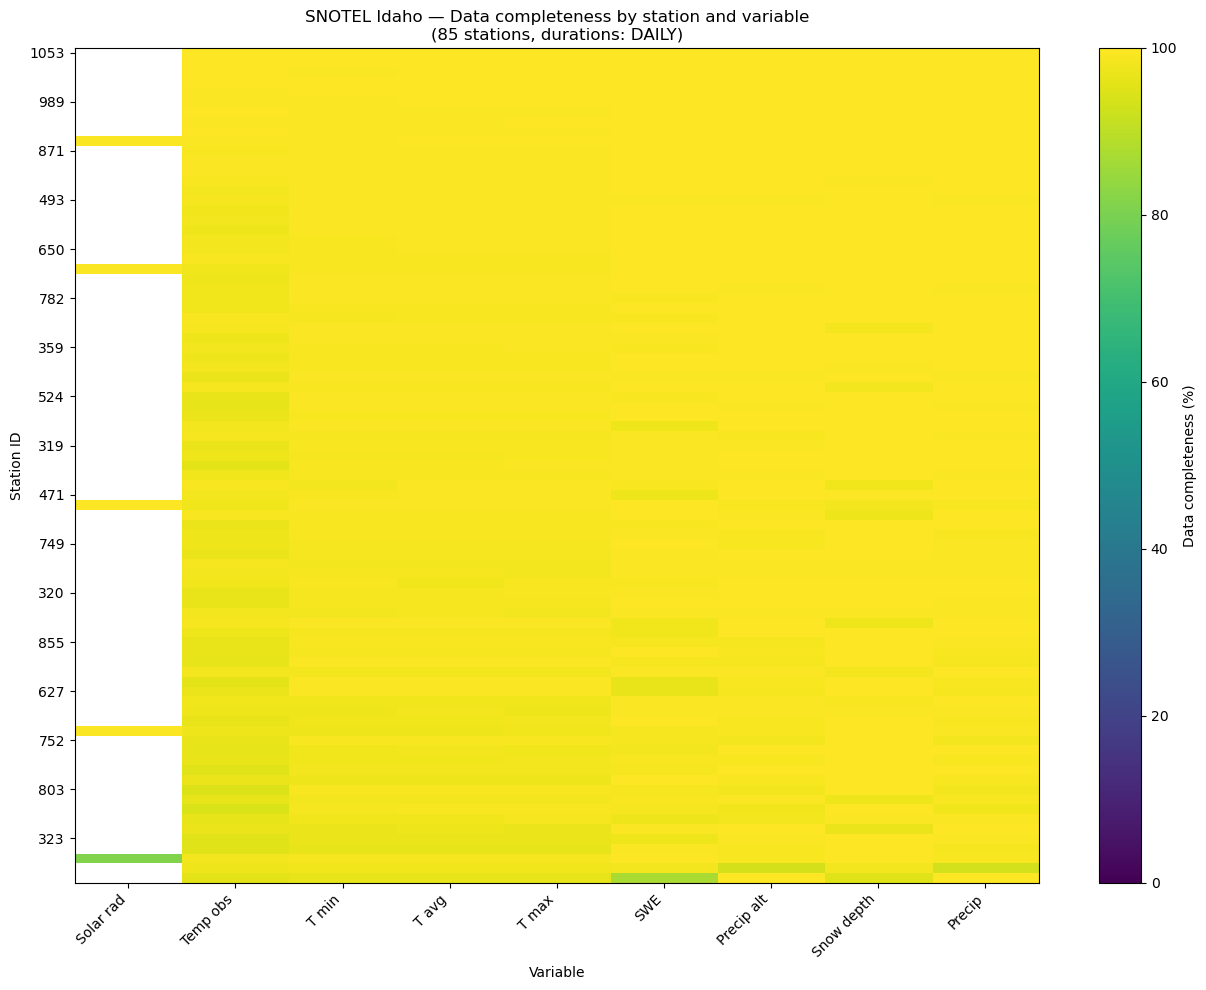

In [8]:
CHUNK_DIRS = [
    OUT_DIR / "awdb_chunks_daily",
    OUT_DIR / "awdb_chunks_radiation",
]
TARGET_VARS = None
TARGET_DURATIONS = ["DAILY"]
YTICK_STEP = 5

VAR_LABELS = {
    "WTEQ": "SWE",
    "SNWD": "Snow depth",
    "PRCP": "Precip",
    "PREC": "Precip alt",
    "TAVG": "T avg",
    "TMIN": "T min",
    "TMAX": "T max",
    "TOBS": "Temp obs",
    "SRADV": "Solar rad",
    "SWINV": "SW in",
    "SWOTV": "SW out",
    "LWINV": "LW in",
    "LWOTV": "LW out",
    "WSPDV": "Wind speed",
    "WDIRV": "Wind dir",
    "RHUM": "RH",
}

files = []
for d in CHUNK_DIRS:
    files.extend(sorted(glob.glob(str(d / "*.csv"))))

print("Files trovati:", len(files))
dfs = [pd.read_csv(f) for f in files if file_ready(f)]
df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame(columns=["stationTriplet","elementCd","duration","date","value"])

df["date"] = pd.to_datetime(df["date"], errors="coerce")

if TARGET_VARS is not None:
    df = df[df["elementCd"].isin(TARGET_VARS)].copy()
if TARGET_DURATIONS is not None:
    df = df[df["duration"].isin(TARGET_DURATIONS)].copy()

coverage = (
    df.groupby(["stationTriplet", "elementCd"])
      .agg(
          n_total=("value", "size"),
          n_valid=("value", lambda x: x.notna().sum()),
      )
      .reset_index()
)
coverage["coverage_pct"] = 100 * coverage["n_valid"] / coverage["n_total"]

mat = coverage.pivot(index="stationTriplet", columns="elementCd", values="coverage_pct")
mat.index = mat.index.str.split(":").str[0]

station_rank = mat.mean(axis=1).sort_values(ascending=False).index
mat = mat.loc[station_rank]

var_rank = mat.mean(axis=0).sort_values(ascending=True).index
mat = mat[var_rank]

xlabels = [VAR_LABELS.get(v, v) for v in mat.columns]

plt.figure(figsize=(13, 10))
im = plt.imshow(mat, aspect="auto", interpolation="none", vmin=0, vmax=100)

yticks = np.arange(0, len(mat.index), YTICK_STEP)
plt.yticks(yticks, mat.index[::YTICK_STEP])
plt.xticks(range(len(mat.columns)), xlabels, rotation=45, ha="right")

cbar = plt.colorbar(im)
cbar.set_label("Data completeness (%)")

plt.xlabel("Variable")
plt.ylabel("Station ID")
plt.title(
    f"SNOTEL Idaho — Data completeness by station and variable\n"
    f"({len(mat.index)} stations, durations: {', '.join(sorted(df['duration'].dropna().unique()))})"
)
plt.tight_layout()
plt.show()

## 8. Synoptic vs non-Synoptic

in_synoptic
False    71
True     14
Name: station_id, dtype: int64


/var/folders/53/jny60bpd0_78tjvn_gcpwv0c0000gn/T/ipykernel_3418/1687487129.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  meta["start"] = pd.to_datetime(meta["start"], errors="coerce")


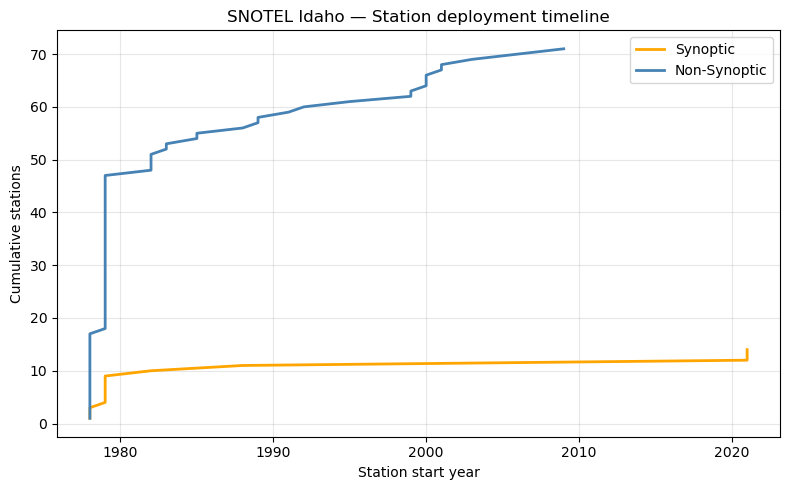

In [9]:
MATCHES_CSV = OUT_DIR / "matches_snotel_synoptic.csv"
syn = pd.read_csv(MATCHES_CSV)
syn_ids = syn["SNOTEL_source_id"].astype(str)

meta = pd.read_csv(STATION_META_CSV, dtype={"station_triplet":"string"})
meta["station_id"] = meta["station_triplet"].str.split(":").str[0]
meta["start"] = pd.to_datetime(meta["start"], errors="coerce")
meta["start_year"] = meta["start"].dt.year
meta["in_synoptic"] = meta["station_id"].isin(syn_ids)

print(meta.groupby("in_synoptic")["station_id"].nunique())

plt.figure(figsize=(8,5))
for flag,label,color in [
    (True, "Synoptic", "orange"),
    (False, "Non-Synoptic", "steelblue"),
]:
    d = meta.loc[meta["in_synoptic"] == flag, "start_year"].dropna().sort_values()
    y = np.arange(1, len(d) + 1)
    plt.plot(d, y, lw=2, label=label, color=color)

plt.xlabel("Station start year")
plt.ylabel("Cumulative stations")
plt.title("SNOTEL Idaho — Station deployment timeline")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

/Users/irene/miniconda3/envs/hydromet/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


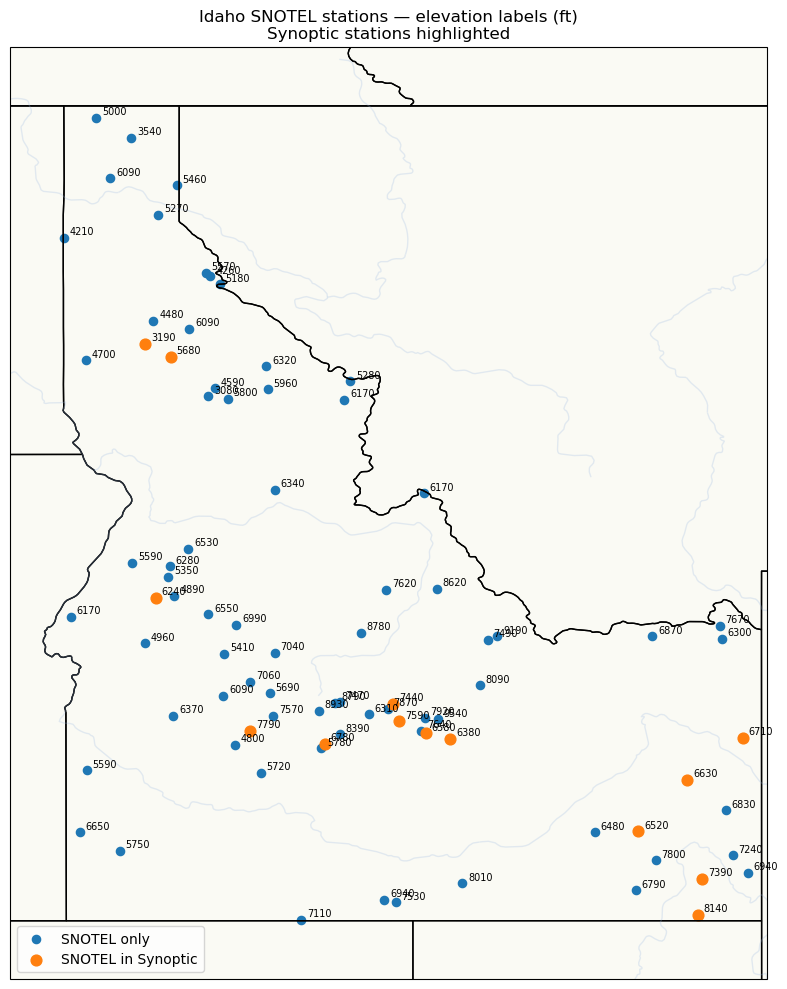

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ============================================================
# LOAD METADATA
# ============================================================
meta = pd.read_csv(
    "out/snotel_official_inventory_idaho_clean.csv",
    dtype={"station_triplet": "string", "station_id": "string"}
)

syn = pd.read_csv("out/matches_snotel_synoptic.csv")
syn_ids = syn["SNOTEL_source_id"].astype(str)

meta["in_synoptic"] = meta["station_id"].astype(str).isin(syn_ids)

# ============================================================
# USE REAL COLUMN NAMES FROM YOUR FILE
# ============================================================
lat_col = "lat"
lon_col = "lon"
ele_col = "elev_ft"   # cambia in "elev_m" se vuoi metri

plot_df = meta[[lat_col, lon_col, ele_col, "station_id", "site_name", "in_synoptic"]].dropna().copy()

syn_df = plot_df[plot_df["in_synoptic"]]
nosyn_df = plot_df[~plot_df["in_synoptic"]]

# ============================================================
# PLOT
# ============================================================
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-117.5, -111.0, 41.5, 49.5], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.STATES, linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.RIVERS, alpha=0.25)

ax.scatter(
    nosyn_df[lon_col],
    nosyn_df[lat_col],
    s=35,
    marker="o",
    label="SNOTEL only",
    transform=ccrs.PlateCarree()
)

ax.scatter(
    syn_df[lon_col],
    syn_df[lat_col],
    s=60,
    marker="o",
    label="SNOTEL in Synoptic",
    transform=ccrs.PlateCarree()
)

# quota accanto al punto
for _, row in plot_df.iterrows():
    ax.text(
        row[lon_col] + 0.05,
        row[lat_col] + 0.03,
        f"{int(round(row[ele_col]))}",
        fontsize=7,
        transform=ccrs.PlateCarree()
    )

ax.set_title("Idaho SNOTEL stations — elevation labels (ft)\nSynoptic stations highlighted")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()

N Synoptic: 14
N Non-Synoptic: 71

Mean elevation
  Synoptic:      6647.1
  Non-Synoptic:  6444.4

Median elevation
  Synoptic:      6670.0
  Non-Synoptic:  6320.0

KS test
KstestResult(statistic=np.float64(0.3209255533199195), pvalue=np.float64(0.13989399138629427), statistic_location=np.int64(6370), statistic_sign=np.int8(-1))


/var/folders/53/jny60bpd0_78tjvn_gcpwv0c0000gn/T/ipykernel_3418/2038780067.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


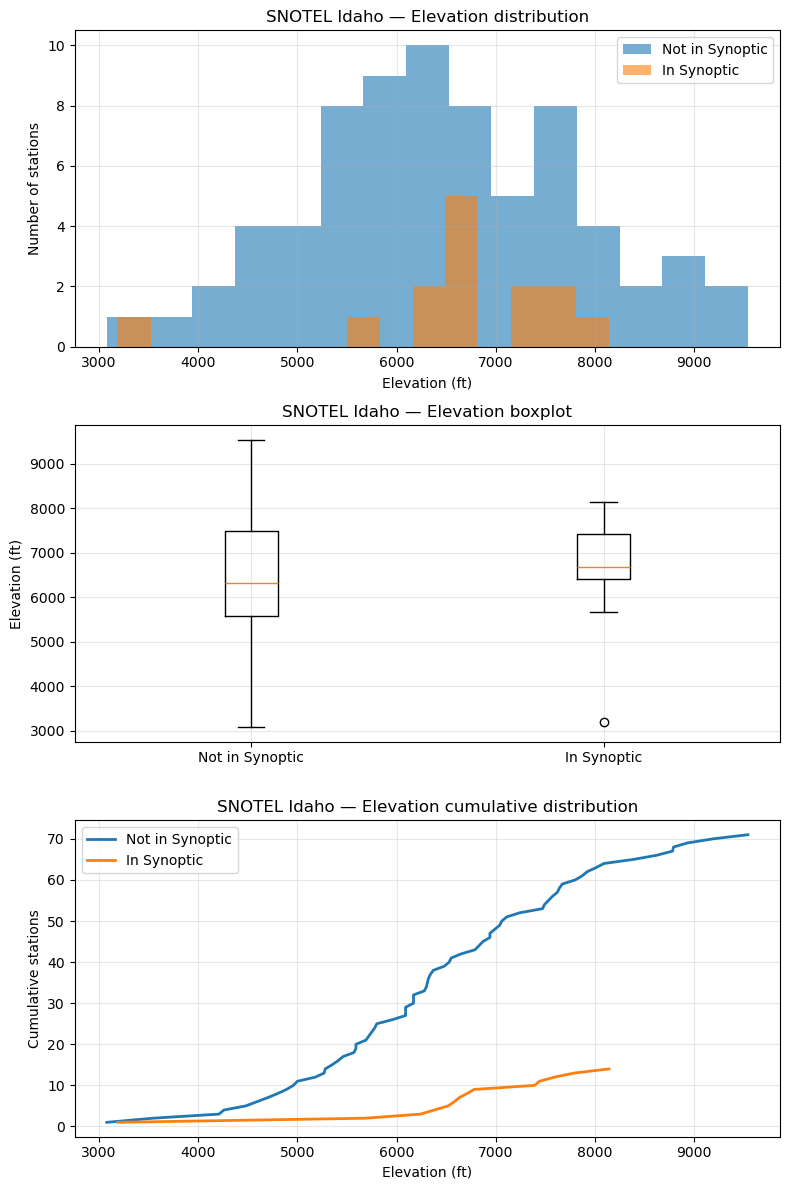

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

# ============================================================
# LOAD DATA
# ============================================================
meta = pd.read_csv(
    "out/snotel_official_inventory_idaho_clean.csv",
    dtype={"station_triplet": "string", "station_id": "string"}
)

syn = pd.read_csv("out/matches_snotel_synoptic.csv")
syn_ids = syn["SNOTEL_source_id"].astype(str)

meta["in_synoptic"] = meta["station_id"].astype(str).isin(syn_ids)

# scegli quota: elev_ft oppure elev_m
elev_col = "elev_ft"

df = meta[[ "station_id", "site_name", elev_col, "in_synoptic"]].dropna().copy()

syn_elev = df.loc[df["in_synoptic"], elev_col]
nosyn_elev = df.loc[~df["in_synoptic"], elev_col]

print("N Synoptic:", len(syn_elev))
print("N Non-Synoptic:", len(nosyn_elev))
print()
print("Mean elevation")
print("  Synoptic:     ", round(syn_elev.mean(), 1))
print("  Non-Synoptic: ", round(nosyn_elev.mean(), 1))
print()
print("Median elevation")
print("  Synoptic:     ", round(syn_elev.median(), 1))
print("  Non-Synoptic: ", round(nosyn_elev.median(), 1))
print()
print("KS test")
print(ks_2samp(syn_elev, nosyn_elev))

# ============================================================
# FIGURE
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(8, 12))

# ------------------------------------------------------------
# 1. Histogram
# ------------------------------------------------------------
bins = 15

axes[0].hist(
    nosyn_elev,
    bins=bins,
    alpha=0.6,
    label="Not in Synoptic"
)

axes[0].hist(
    syn_elev,
    bins=bins,
    alpha=0.6,
    label="In Synoptic"
)

axes[0].set_xlabel("Elevation (ft)")
axes[0].set_ylabel("Number of stations")
axes[0].set_title("SNOTEL Idaho — Elevation distribution")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ------------------------------------------------------------
# 2. Boxplot
# ------------------------------------------------------------
axes[1].boxplot(
    [nosyn_elev, syn_elev],
    labels=["Not in Synoptic", "In Synoptic"]
)

axes[1].set_ylabel("Elevation (ft)")
axes[1].set_title("SNOTEL Idaho — Elevation boxplot")
axes[1].grid(alpha=0.3)

# ------------------------------------------------------------
# 3. CDF
# ------------------------------------------------------------
for data, label in [
    (nosyn_elev.sort_values(), "Not in Synoptic"),
    (syn_elev.sort_values(), "In Synoptic")
]:
    y = range(1, len(data) + 1)
    axes[2].plot(data, y, lw=2, label=label)

axes[2].set_xlabel("Elevation (ft)")
axes[2].set_ylabel("Cumulative stations")
axes[2].set_title("SNOTEL Idaho — Elevation cumulative distribution")
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
import pandas as pd
from zeep import Client
from zeep.transports import Transport
from requests import Session
import os
import time
import numpy as np

WSDL = "https://wcc.sc.egov.usda.gov/awdbWebService/services?WSDL"

OUT_DIR = "out/snow_v3"
os.makedirs(OUT_DIR, exist_ok=True)

ELEMENTS = ["WTEQ", "TAVG", "PREC"]  # inizia solo con WTEQ
START_YEAR = 1980
END_YEAR = 2026

meta = pd.read_csv(
    "out/snotel_official_inventory_idaho_clean.csv",
    dtype={"station_triplet": "string"}
)
triplets = meta["station_triplet"].dropna().unique().tolist()

session = Session()
transport = Transport(session=session, timeout=120)
client = Client(wsdl=WSDL, transport=transport)

fail_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    out_file = f"{OUT_DIR}/awdb_all_{year}.csv"

    if os.path.exists(out_file) and os.path.getsize(out_file) > 1000:
        print(f"[SKIP] {year} already downloaded")
        continue

    print(f"\n=== WATER YEAR {year} ===")
    begin = f"{year-1}-10-01"
    end   = f"{year}-09-30"

    rows = []

    for i, triplet in enumerate(triplets, start=1):
        print(f"{year} [{i}/{len(triplets)}] {triplet}")

        for element in ELEMENTS:
            try:
                data = client.service.getData(
                    stationTriplets=[triplet],
                    elementCd=element,
                    ordinal=1,
                    duration="DAILY",
                    getFlags=False,
                    beginDate=begin,
                    endDate=end,
                )

                if not data:
                    continue

                d0 = data[0]
                values = getattr(d0, "values", None)

                if values is None or len(values) == 0:
                    continue

                values = np.array(values, dtype="float64")
                values[values <= -9990] = np.nan

                expected_dates = pd.date_range(begin, end, freq="D")
                n = min(len(expected_dates), len(values))

                for j in range(n):
                    rows.append({
                        "stationTriplet": triplet,
                        "date": expected_dates[j],
                        "value": values[j],
                        "elementCd": element,
                        "water_year": year
                    })

            except Exception as e:
                fail_rows.append({
                    "water_year": year,
                    "stationTriplet": triplet,
                    "elementCd": element,
                    "error": str(e)
                })
                print("ERROR:", triplet, element, e)

            time.sleep(0.1)

    df_out = pd.DataFrame(rows)

    if len(df_out) == 0:
        print(f"WARNING: year {year} empty -> not saved")
        continue

    tmp_file = out_file + ".tmp"
    df_out.to_csv(tmp_file, index=False)
    os.replace(tmp_file, out_file)

    print(f"[SAVED] {out_file} rows={len(df_out)}")

fail_df = pd.DataFrame(fail_rows)
fail_df.to_csv("out/awdb_all_v2_failures.csv", index=False)
print("[DONE]")

[SKIP] 1980 already downloaded
[SKIP] 1981 already downloaded
[SKIP] 1982 already downloaded
[SKIP] 1983 already downloaded
[SKIP] 1984 already downloaded
[SKIP] 1985 already downloaded
[SKIP] 1986 already downloaded
[SKIP] 1987 already downloaded
[SKIP] 1988 already downloaded
[SKIP] 1989 already downloaded
[SKIP] 1990 already downloaded
[SKIP] 1991 already downloaded
[SKIP] 1992 already downloaded
[SKIP] 1993 already downloaded
[SKIP] 1994 already downloaded
[SKIP] 1995 already downloaded
[SKIP] 1996 already downloaded
[SKIP] 1997 already downloaded
[SKIP] 1998 already downloaded
[SKIP] 1999 already downloaded
[SKIP] 2000 already downloaded
[SKIP] 2001 already downloaded
[SKIP] 2002 already downloaded
[SKIP] 2003 already downloaded
[SKIP] 2004 already downloaded
[SKIP] 2005 already downloaded
[SKIP] 2006 already downloaded
[SKIP] 2007 already downloaded
[SKIP] 2008 already downloaded
[SKIP] 2009 already downloaded
[SKIP] 2010 already downloaded
[SKIP] 2011 already downloaded
[SKIP] 2

In [24]:
import pandas as pd
from pathlib import Path

OUT_DIR = Path("out/snow_v3")

# find all yearly files
files = sorted(OUT_DIR.glob("awdb_all_*.csv"))

print("Files trovati:")
for f in files:
    print(" -", f.name)

# -------------------------
# helper function to read and standardize one file
# -------------------------
def read_one(f):
    df = pd.read_csv(
        f,
        dtype={
            "stationTriplet": "string",
            "elementCd": "category",
            "value": "float32"
        },
        parse_dates=["date"]
    )

    # water year
    if "water_year" not in df.columns:
        df["water_year"] = (
            df["date"].dt.year +
            (df["date"].dt.month >= 10).astype(int)
        ).astype("int16")
    else:
        df["water_year"] = df["water_year"].astype("int16")

    # station_id
    if "station_id" not in df.columns:
        df["station_id"] = (
            df["stationTriplet"].str.split(":").str[0].astype("category")
        )
    else:
        df["station_id"] = df["station_id"].astype("category")

    return df


# -------------------------
# concatenate all years
# -------------------------
df_daily = pd.concat((read_one(f) for f in files), ignore_index=True)

# final columns
cols = ["stationTriplet", "date", "value", "elementCd", "water_year", "station_id"]
df_daily = df_daily[[c for c in cols if c in df_daily.columns]]

# -------------------------
# basic checks
# -------------------------
print("\nShape:", df_daily.shape)
print(df_daily.dtypes)
print("\nElementi:", sorted(df_daily["elementCd"].dropna().unique()))
print("\nWater years:", sorted(df_daily["water_year"].unique())) 

Files trovati:
 - awdb_all_1980.csv
 - awdb_all_1981.csv
 - awdb_all_1982.csv
 - awdb_all_1983.csv
 - awdb_all_1984.csv
 - awdb_all_1985.csv
 - awdb_all_1986.csv
 - awdb_all_1987.csv
 - awdb_all_1988.csv
 - awdb_all_1989.csv
 - awdb_all_1990.csv
 - awdb_all_1991.csv
 - awdb_all_1992.csv
 - awdb_all_1993.csv
 - awdb_all_1994.csv
 - awdb_all_1995.csv
 - awdb_all_1996.csv
 - awdb_all_1997.csv
 - awdb_all_1998.csv
 - awdb_all_1999.csv
 - awdb_all_2000.csv
 - awdb_all_2001.csv
 - awdb_all_2002.csv
 - awdb_all_2003.csv
 - awdb_all_2004.csv
 - awdb_all_2005.csv
 - awdb_all_2006.csv
 - awdb_all_2007.csv
 - awdb_all_2008.csv
 - awdb_all_2009.csv
 - awdb_all_2010.csv
 - awdb_all_2011.csv
 - awdb_all_2012.csv
 - awdb_all_2013.csv
 - awdb_all_2014.csv
 - awdb_all_2015.csv
 - awdb_all_2016.csv
 - awdb_all_2017.csv
 - awdb_all_2018.csv
 - awdb_all_2019.csv
 - awdb_all_2020.csv
 - awdb_all_2021.csv
 - awdb_all_2022.csv
 - awdb_all_2023.csv
 - awdb_all_2024.csv
 - awdb_all_2025.csv
 - awdb_all_2026.cs

In [25]:
df_daily.head()

,stationTriplet,date,value,elementCd,water_year,station_id
0,423:ID:SNTL,1979-10-01,32.0,TAVG,1980,423
1,484:ID:SNTL,1979-10-01,0.0,WTEQ,1980,484
2,484:ID:SNTL,1979-10-02,0.0,WTEQ,1980,484
3,484:ID:SNTL,1979-10-03,0.0,WTEQ,1980,484
4,484:ID:SNTL,1979-10-04,0.0,WTEQ,1980,484


In [26]:
df_daily["station_id"].nunique()

85

In [27]:
df_daily["date"].nunique()

16841

In [28]:
df_daily["date"].min(), df_daily["date"].max()

(Timestamp('1979-10-01 00:00:00'), Timestamp('2026-03-19 00:00:00'))

## 9. Basic data coverage summary

Summarize the number of records, time span, and SWE range for each station.

In [29]:
summary = df_daily.groupby("station_id").agg(
    n=("value", "count"),
    start=("date", "min"),
    end=("date", "max"),
    min_swe=("value", "min"),
    max_swe=("value", "max")
).reset_index()

summary.head()

,station_id,n,start,end,min_swe,max_swe
0,1016,26690,2001-10-01,2026-03-19,-12.28,79.879997
1,1053,24539,2003-10-01,2026-03-19,-14.98,86.900002
2,1081,21286,2005-10-01,2026-03-19,-12.82,85.459999
3,1142,17986,2008-10-01,2026-03-19,-6.52,78.080002
4,1299,5035,2020-10-01,2026-03-19,-9.58,71.779999


## 10. SWE climatology and recent water years

Build a statewide SWE climatology and compare it with the most recent five water years.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

swe = df_daily[df_daily["elementCd"] == "WTEQ"].copy()

# water year already defined
# day of water year (1 = Oct 1)
wy_start = pd.to_datetime((swe["water_year"] - 1).astype(str) + "-10-01")
swe["doy_wy"] = (swe["date"] - wy_start).dt.days + 1

Water years: [np.int16(2022), np.int16(2023), np.int16(2024), np.int16(2025), np.int16(2026)]


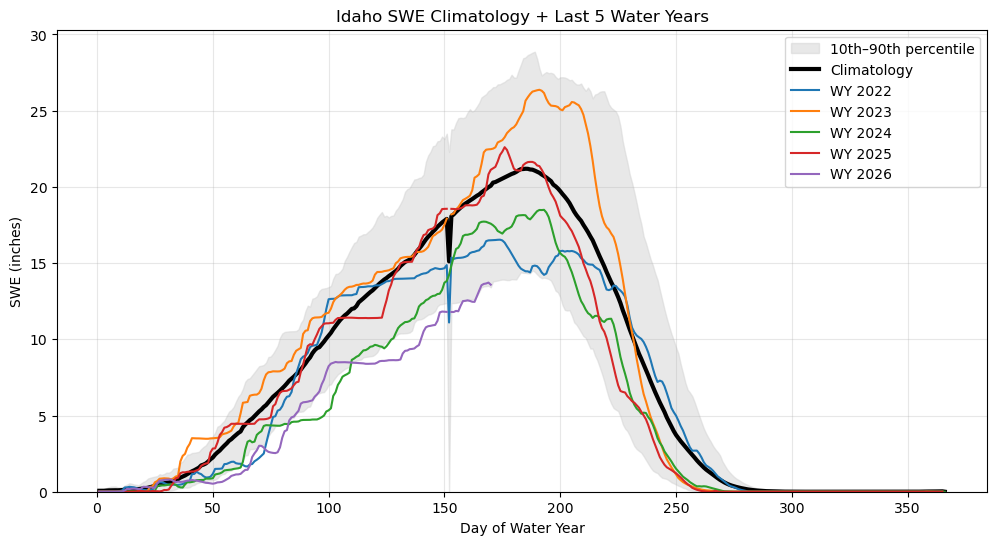

In [39]:
# -------------------------
# CLIMATOLOGY (mean + percentiles across years)
# -------------------------

# First: aggregate stations -> one Idaho value per year and day of water year
yearly_idaho = (
    swe.groupby(["water_year", "doy_wy"])["value"]
    .mean()
    .reset_index()
)

# Then: climatological mean and percentiles across years
clim_mean = yearly_idaho.groupby("doy_wy")["value"].mean()
clim_p10  = yearly_idaho.groupby("doy_wy")["value"].quantile(0.10)
clim_p90  = yearly_idaho.groupby("doy_wy")["value"].quantile(0.90)

# -------------------------
# LAST 5 WATER YEARS
# -------------------------

last_wys = sorted(swe["water_year"].unique())[-5:]
print("Water years:", last_wys)

recent = yearly_idaho[yearly_idaho["water_year"].isin(last_wys)].copy()

# -------------------------
# PLOT
# -------------------------

plt.figure(figsize=(12,6))

plt.fill_between(
    clim_mean.index,
    clim_p10,
    clim_p90,
    color="lightgrey",
    alpha=0.5,
    label="10th–90th percentile"
)

plt.plot(
    clim_mean.index,
    clim_mean.values,
    color="black",
    linewidth=3,
    label="Climatology"
)

for wy in last_wys:
    sub = recent[recent["water_year"] == wy]
    plt.plot(sub["doy_wy"], sub["value"], label=f"WY {wy}")

plt.title("Idaho SWE Climatology + Last 5 Water Years")
plt.xlabel("Day of Water Year")
plt.ylabel("SWE (inches)")
plt.ylim(bottom=0)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [40]:
meta


,station_triplet,station_id,site_name,lat,lon,elev_ft,elev_m,county,huc,start,start_year,por_years_approx,source,elev_band
0,306:ID:SNTL,306,Atlanta Summit (306),43.76,-115.24,7570,2307.336,Elmore,Bald Mountain Creek-Middle Fork Boise River (1...,1978-October,1978,48,SNOTEL_OFFICIAL,7000-9000
1,312:ID:SNTL,312,Banner Summit (312),44.30,-115.23,7040,2145.792,Boise,Canyon Creek (170501200202),1979-October,1979,47,SNOTEL_OFFICIAL,7000-9000
2,319:ID:SNTL,319,Bear Basin (319),44.95,-116.14,5350,1630.680,Adams,Little Goose Creek-Goose Creek (170602100104),1979-October,1979,47,SNOTEL_OFFICIAL,5000-7000
3,320:ID:SNTL,320,Bear Canyon (320),43.74,-113.94,7920,2414.016,Custer,Upper Star Hope Creek (170402180101),1979-October,1979,47,SNOTEL_OFFICIAL,7000-9000
4,323:ID:SNTL,323,Bear Mountain (323),48.31,-116.07,5460,1664.208,Bonner,Middle Lightning Creek (170102131202),1979-October,1979,47,SNOTEL_OFFICIAL,5000-7000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,845:ID:SNTL,845,Vienna Mine (845),43.80,-114.85,8930,2721.864,Blaine,Smiley Creek (170602010201),1978-October,1978,48,SNOTEL_OFFICIAL,7000-9000
81,855:ID:SNTL,855,West Branch (855),45.07,-116.45,5590,1703.832,Adams,Upper Weiser River (170501240201),1979-October,1979,47,SNOTEL_OFFICIAL,5000-7000
82,860:ID:SNTL,860,White Elephant (860),44.53,-111.41,7670,2337.816,Fremont,Coffee Pot Creek-Henrys Fork (170402020305),1979-October,1979,47,SNOTEL_OFFICIAL,7000-9000
83,867:ID:SNTL,867,Wildhorse Divide (867),42.76,-112.48,6480,1975.104,Bannock,Mink Creek (170402080504),1979-October,1979,47,SNOTEL_OFFICIAL,5000-7000


## 11. Elevation-band diagnostics

Assign stations to elevation bands and compare SWE behavior across altitude ranges.

In [41]:
import pandas as pd

bins = [0, 5000, 7000, 9000, 20000]
labels = ["<5000", "5000-7000", "7000-9000", ">9000"]

meta["elev_band"] = pd.cut(
    meta["elev_ft"],
    bins=bins,
    labels=labels
)

## 10. SWE climatology and recent water years

Build a statewide SWE climatology and compare it with the most recent five water years.

In [42]:
meta["station_id"] = meta["station_id"].astype(str)
df_daily["station_id"] = df_daily["station_id"].astype(str)

swe = df_daily[df_daily["elementCd"] == "WTEQ"].copy()

swe = swe.merge(
    meta[["station_id", "elev_band"]],
    on="station_id",
    how="left"
)

In [43]:
wy_start = pd.to_datetime((swe["water_year"] - 1).astype(str) + "-10-01")
swe["doy_wy"] = (swe["date"] - wy_start).dt.days + 1

In [44]:
clim = (
    swe.groupby(["elev_band", "station_id", "doy_wy"])["value"]
    .mean()
    .groupby(["elev_band", "doy_wy"])
    .mean()
)

/var/folders/53/jny60bpd0_78tjvn_gcpwv0c0000gn/T/ipykernel_30031/545747186.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  swe.groupby(["elev_band", "station_id", "doy_wy"])["value"]
/var/folders/53/jny60bpd0_78tjvn_gcpwv0c0000gn/T/ipykernel_30031/545747186.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["elev_band", "doy_wy"])


In [45]:
last_wys = sorted(swe["water_year"].unique())[-5:]

recent = (
    swe[swe["water_year"].isin(last_wys)]
    .groupby(["elev_band", "water_year", "station_id", "doy_wy"])["value"]
    .mean()
    .groupby(["elev_band", "water_year", "doy_wy"])
    .mean()
    .reset_index()
)

/var/folders/53/jny60bpd0_78tjvn_gcpwv0c0000gn/T/ipykernel_30031/981468290.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["elev_band", "water_year", "station_id", "doy_wy"])["value"]
/var/folders/53/jny60bpd0_78tjvn_gcpwv0c0000gn/T/ipykernel_30031/981468290.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["elev_band", "water_year", "doy_wy"])


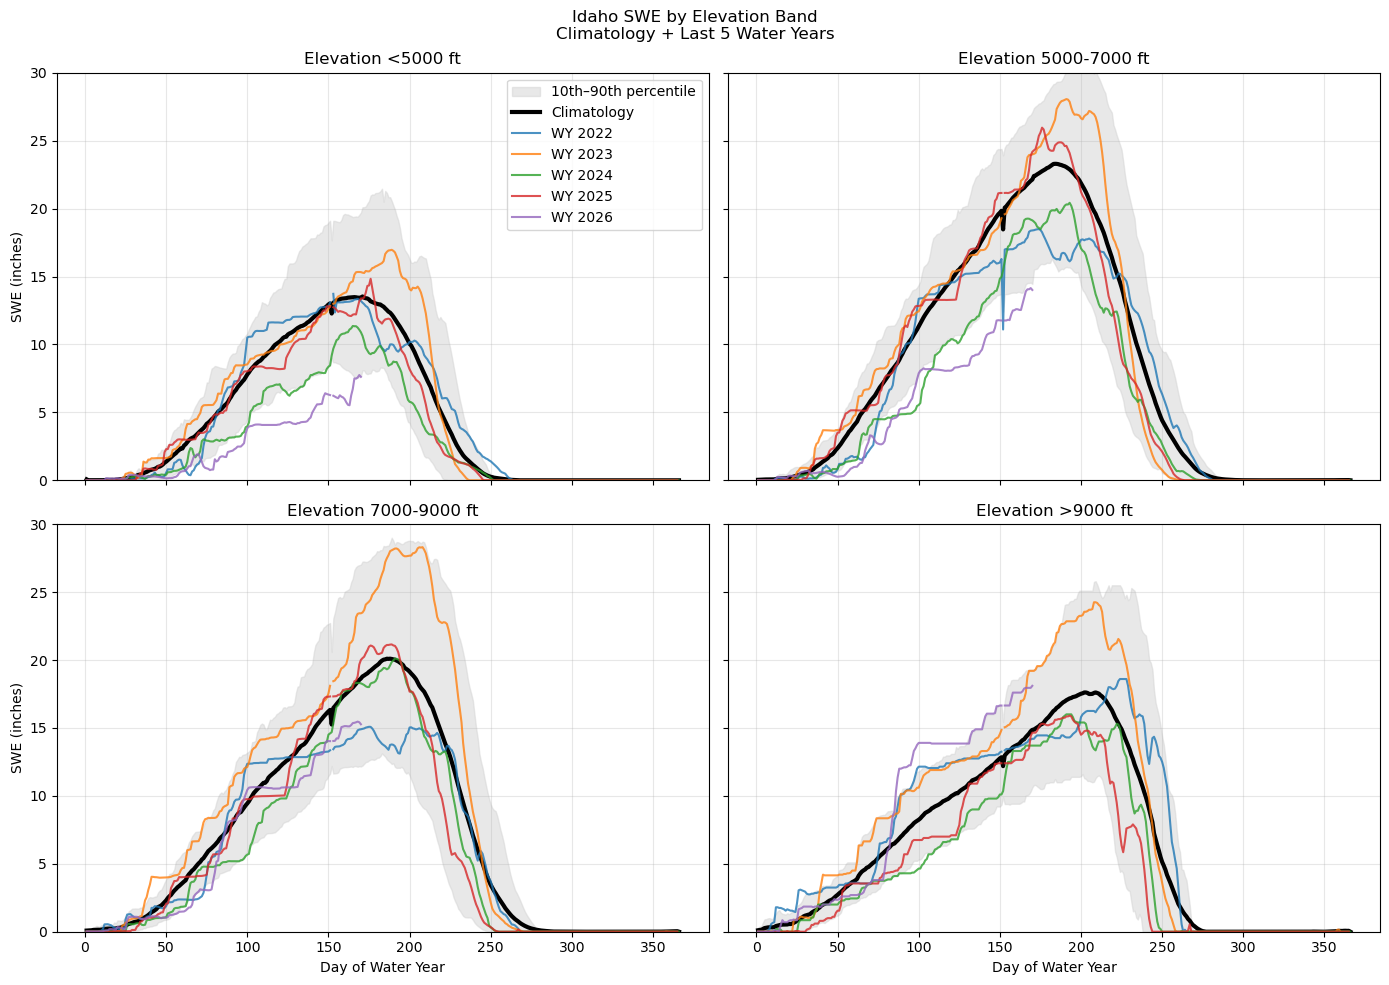

In [46]:
import matplotlib.pyplot as plt

# -------------------------
# STEP 1: aggregate stations → one value per band, year, day
# -------------------------

band_year = (
    swe.groupby(["elev_band", "water_year", "doy_wy"], observed=True)["value"]
    .mean()
    .reset_index()
)

# -------------------------
# STEP 2: climatology across years
# -------------------------

clim_mean = (
    band_year.groupby(["elev_band", "doy_wy"], observed=True)["value"]
    .mean()
)

clim_p10 = (
    band_year.groupby(["elev_band", "doy_wy"], observed=True)["value"]
    .quantile(0.10)
)

clim_p90 = (
    band_year.groupby(["elev_band", "doy_wy"], observed=True)["value"]
    .quantile(0.90)
)

# -------------------------
# STEP 3: last 5 water years (già aggregati!)
# -------------------------

last_wys = sorted(band_year["water_year"].unique())[-5:]

recent = band_year[band_year["water_year"].isin(last_wys)].copy()

# -------------------------
# STEP 4: plot
# -------------------------

fig, axes = plt.subplots(2, 2, figsize=(14,10), sharex=True, sharey=True)

for ax, band in zip(axes.flatten(), labels):

    if band in clim_mean.index.levels[0]:

        cmean = clim_mean.loc[band]
        cp10  = clim_p10.loc[band]
        cp90  = clim_p90.loc[band]

        # 🔹 percentile band (CORRETTA)
        ax.fill_between(
            cmean.index,
            cp10.values,
            cp90.values,
            color="lightgrey",
            alpha=0.5,
            label="10th–90th percentile"
        )

        # 🔹 climatology
        ax.plot(
            cmean.index,
            cmean.values,
            color="black",
            linewidth=3,
            label="Climatology"
        )

    # 🔹 last years
    sub = recent[recent["elev_band"] == band]

    for wy in last_wys:
        s = sub[sub["water_year"] == wy]
        ax.plot(s["doy_wy"], s["value"], label=f"WY {wy}", alpha=0.8)

    ax.set_title(f"Elevation {band} ft")
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

# legend
axes[0,0].legend()

fig.suptitle("Idaho SWE by Elevation Band\nClimatology + Last 5 Water Years")

for ax in axes[-1,:]:
    ax.set_xlabel("Day of Water Year")

for ax in axes[:,0]:
    ax.set_ylabel("SWE (inches)")
ax.set_ylim(0, 30)
plt.tight_layout()
plt.show()

## 12. Temperature and precipitation diagnostics

Reuse the same workflow to build climatologies and recent-year comparisons for `TAVG` and `PREC`.

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

meta["station_id"] = meta["station_id"].astype(str)
df_daily["station_id"] = df_daily["station_id"].astype(str)

def prepare_variable(df, element, meta, labels, is_cumulative=False):
    x = df[df["elementCd"] == element].copy()

    x = x.merge(
        meta[["station_id", "elev_band"]],
        on="station_id",
        how="left"
    )

    # day of water year
    wy_start = pd.to_datetime((x["water_year"] - 1).astype(str) + "-10-01")
    x["doy_wy"] = (x["date"] - wy_start).dt.days + 1

    # se la variabile è cumulata (PREC), trasformala in giornaliera
    if is_cumulative:
        x = x.sort_values(["station_id", "water_year", "date"]).copy()
        x["value"] = x.groupby(["station_id", "water_year"])["value"].diff()

        # il primo giorno resta NaN: opzionalmente mettilo uguale al cumulato del primo giorno
        first_mask = x.groupby(["station_id", "water_year"]).cumcount() == 0
        x.loc[first_mask, "value"] = x.loc[first_mask, "value"].fillna(0)

        # eventuali reset/spike negativi
        x.loc[x["value"] < 0, "value"] = pd.NA

    # climatology
    clim = (
        x.groupby(["elev_band", "station_id", "doy_wy"], observed=True)["value"]
        .mean()
        .groupby(["elev_band", "doy_wy"], observed=True)
        .mean()
    )

    # last 5 water years
    last_wys = sorted(x["water_year"].dropna().unique())[-5:]

    recent = (
        x[x["water_year"].isin(last_wys)]
        .groupby(["elev_band", "water_year", "station_id", "doy_wy"], observed=True)["value"]
        .mean()
        .groupby(["elev_band", "water_year", "doy_wy"], observed=True)
        .mean()
        .reset_index()
    )

    return x, clim, recent, last_wys

## 12. Temperature and precipitation diagnostics

Reuse the same workflow to build climatologies and recent-year comparisons for `TAVG` and `PREC`.

In [48]:
tavg, clim_tavg, recent_tavg, last_wys_tavg = prepare_variable(
    df_daily, "TAVG", meta, labels, is_cumulative=False
)

In [49]:
tmp = df_daily[(df_daily["elementCd"] == "PREC") & (df_daily["station_id"] == "306")].copy()
tmp = tmp.sort_values(["water_year", "date"])
print(tmp[["date", "value"]].head(20))

          date  value
897 1980-10-01    0.0
898 1980-10-02    0.2
899 1980-10-03    0.2
900 1980-10-04    0.2
901 1980-10-05    0.2
902 1980-10-06    0.2
903 1980-10-07    0.2
904 1980-10-08    0.2
905 1980-10-09    0.2
906 1980-10-10    0.2
907 1980-10-11    0.2
908 1980-10-12    0.2
909 1980-10-13    0.7
910 1980-10-14    0.9
911 1980-10-15    0.9
912 1980-10-16    0.9
913 1980-10-17    0.9
914 1980-10-18    0.9
915 1980-10-19    0.9
916 1980-10-20    0.9


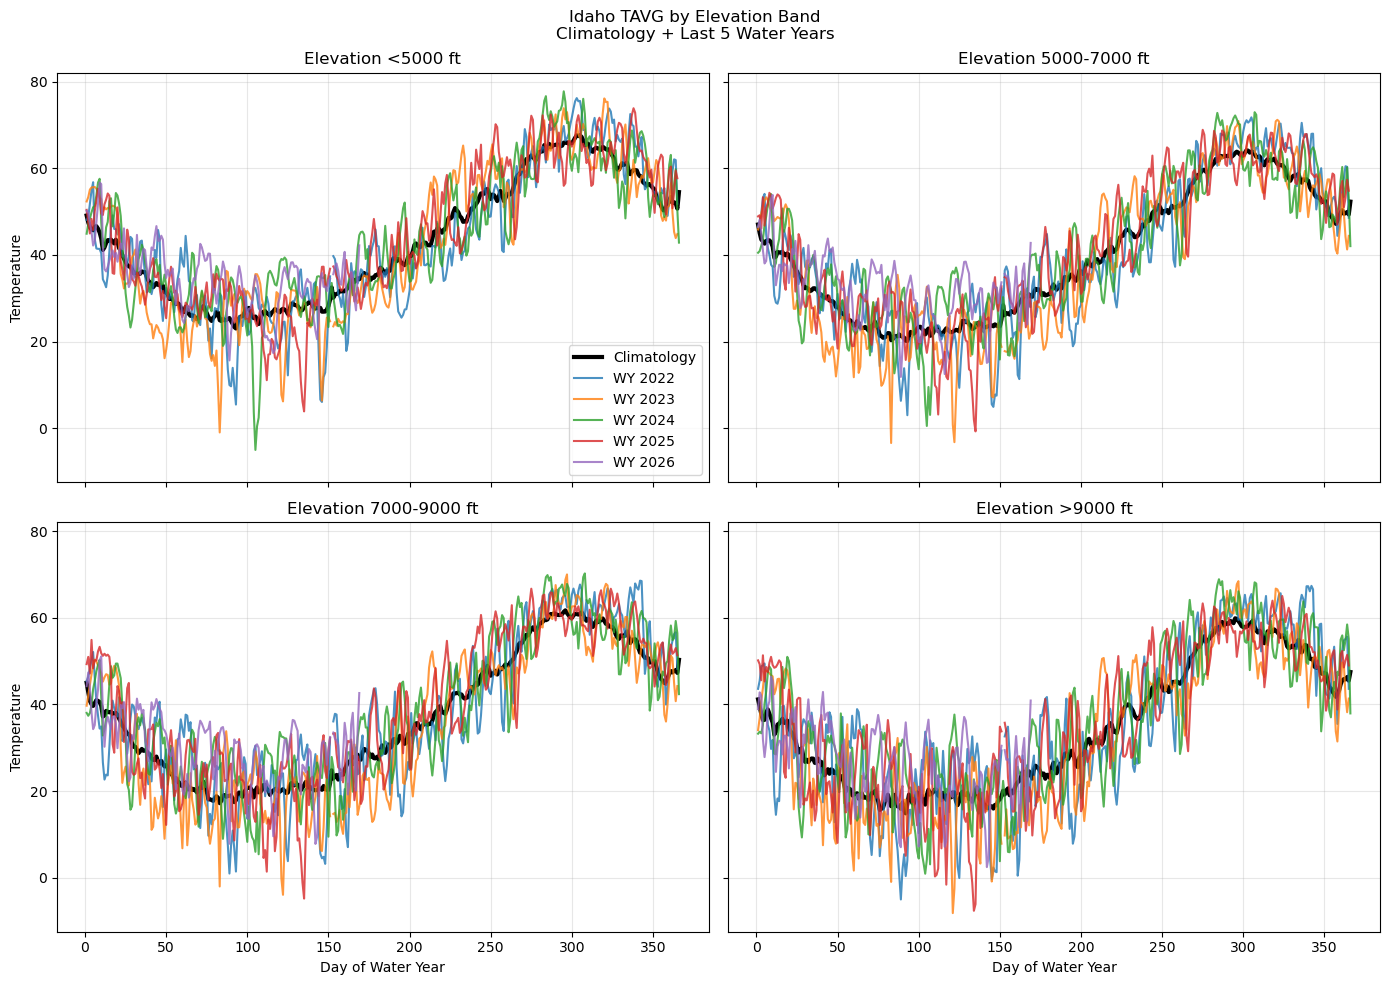

In [50]:
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharex=True, sharey=True)

for ax, band in zip(axes.flatten(), labels):

    # climatology
    if band in clim_tavg.index.levels[0]:
        c = clim_tavg.loc[band]
        ax.plot(c.index, c.values, color="black", linewidth=3, label="Climatology")

    # last years
    sub = recent_tavg[recent_tavg["elev_band"] == band]

    for wy in last_wys_tavg:
        s = sub[sub["water_year"] == wy]
        ax.plot(s["doy_wy"], s["value"], label=f"WY {wy}", alpha=0.8)

    ax.set_title(f"Elevation {band} ft")
    ax.grid(alpha=0.3)

axes[0,0].legend()
fig.suptitle("Idaho TAVG by Elevation Band\nClimatology + Last 5 Water Years")

for ax in axes[-1,:]:
    ax.set_xlabel("Day of Water Year")

for ax in axes[:,0]:
    ax.set_ylabel("Temperature")

plt.tight_layout()
plt.show()

NameError: name 'clim_prec' is not defined

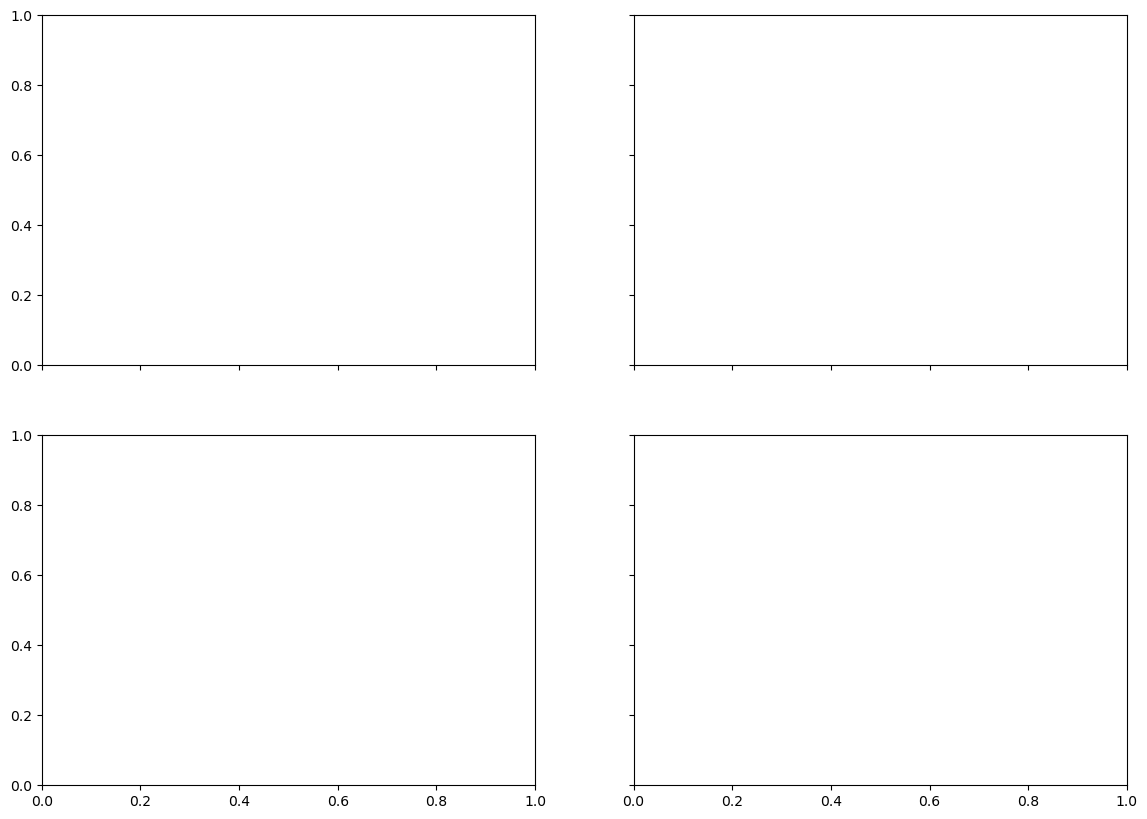

In [51]:
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharex=True, sharey=True)

for ax, band in zip(axes.flatten(), labels):

    # climatology
    if band in clim_prec.index.levels[0]:
        c = clim_prec.loc[band]
        ax.plot(c.index, c.values, color="black", linewidth=3, label="Climatology")

    # last years
    sub = recent_prec[recent_prec["elev_band"] == band]

    for wy in last_wys_prec:
        s = sub[sub["water_year"] == wy]
        ax.plot(s["doy_wy"], s["value"], label=f"WY {wy}", alpha=0.8)

    ax.set_title(f"Elevation {band} ft")
    ax.grid(alpha=0.3)

axes[0,0].legend()
fig.suptitle("Idaho Daily Precipitation by Elevation Band\nClimatology + Last 5 Water Years")

for ax in axes[-1,:]:
    ax.set_xlabel("Day of Water Year")

for ax in axes[:,0]:
    ax.set_ylabel("Precipitation")

plt.tight_layout()
plt.show()